## Kunskapskontroll - PAI25HTD, PAIV26D
EDA över datasetet Housing med självutvärdering i slutet.

### Introduktion  
Genomgång/presentation spelas in och laddas upp i Teams. Syftet med denna EDA är att undersöka datasetet Housing innehållande mäklardata från fastigheter i Californien där målet är att ge svar på datakvalitet, mönster/insikter, outliers (extremvärden), saknade värden (NULL) etc. 
Övergripande struktur för EDA:n enligt följande:

Introduktion  
Datainläsning   
Utforskning och bearbetning  
Visualiseringar  
Slutsatser  
Självutvärdering  

### Datainläsning

In [2]:
# ladda in bibliotek för datahantering, visualisering och numeriska beräkningar
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# läser in data från csv-fil och visa grundläggande information om datan
df = pd.read_csv("housing.csv")
print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


*Kort översikt kring datasetets tabellstruktur - de olika kolumnerna samt de första raderna för att se vilen typ av data de verkar innehålla.*

### Utforskning och bearbetning

In [4]:
# visa mer detaljerad, teknisk information om datan
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
# statistisk översikt
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


df.describe() och df.info() visar en snabbanalys av datan - under df.info() kan vi se att det finns 10 kolumner samt deras datatyper - 9 av dem är av numeriska typen float64 och en av dem är av datatypen str (som är en textsträng - därför kommer den inte dyka upp i en senare korrelationsmatris)
De flesta rader är kompletta utan NULL-värden (20640 st), total_bedrooms avvikter dock med 20433 rader vilket ger 207 rader med saknade värden. Dessa måste i ett senare steg hanteras, antingen genom att tas bort eller fyllas med data (som tex medel-/medianvärdet från de andra raderna). Datan ser annars ut att vara relativt 'ren' vid en första anblick.

df.describe() gör en djupare analys av datan - vi kan t.ex. se att medelåldern på ett hus är 28.6 år, minst antal total_rooms är 2. Totalt antal rum ser vid första anblick lite off ut - det är för att antal sovrum är för hela populationen och inte per enskilt hus. Då första raden, count, anger antal rader utan null-värden kan vi här återigen se hur det skiljer sig åt för kolumnen total_bedrooms. Vi kan även läsa ut att medelvärdet och medianen skiljer sig åt för vissa kolumner - median_house_value är ett sådant exempel.
Kolumnen housing_median_age har ett däremot snarlika medel- och medianvärden - medelvärde på 28.6 år medan medianen (50%) ligger på 29.
Värt att notera - describe() tar enbart med kolumnerna av datatypen float, ocean_proximity som är en textsträng (str) exkluderas per automatik.  

In [6]:
# skapa nytt nyckeltal: antal rum per hushåll
df['rooms_per_household'] = df['total_rooms'] / df['households']

# Visa statistisk översikt av det nya nyckeltalet
df['rooms_per_household'].describe()

count    20640.000000
mean         5.429000
std          2.474173
min          0.846154
25%          4.440716
50%          5.229129
75%          6.052381
max        141.909091
Name: rooms_per_household, dtype: float64

Total_rooms dividerat med antal hushåll för att få ett genomsnittligt värde och en outlier

In [7]:
# undersök fördelningen i "ocean_proximity"
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Dessa celler ger en mer rättvis och lättöverskådlig bild över rumsfördelningen men visar också en eventuell outlier eller fel i datan; medel- och medianvärdet över antal rum är snarlika, maxantalet ligger däremot på 141 rum.
Text-kolumen ocean_proximity har även den en intressant markör - enbart 5 rader har "Island" i den kolumnen vilket kommer påverka vidare analyser med sitt statistiskt lilla underlag. Kategorin "<1H Ocean" dominerar däremot i den kolumnen.  

In [8]:
# undersök om det finns några saknade värden
print(df.isnull().sum())

# hantera saknade värden genom att fylla i dem med medianen av respektive kolumn
cols_with_null = df.columns[df.isnull().any()]
for col in cols_with_null:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

longitude                0
latitude                 0
housing_median_age       0
total_rooms              0
total_bedrooms         207
population               0
households               0
median_income            0
median_house_value       0
ocean_proximity          0
rooms_per_household      0
dtype: int64
longitude              0
latitude               0
housing_median_age     0
total_rooms            0
total_bedrooms         0
population             0
households             0
median_income          0
median_house_value     0
ocean_proximity        0
rooms_per_household    0
dtype: int64


Här identifieras kolumner med saknade värden - det är logiskt att det saknas i både bedrooms_per_household och i total_bedrooms - bedrooms_per_household beräknas på total_bedrooms.

*För att hantera saknade värden används en loop som identifierar vilka kolumner som innehåller NULL-värden för att sedan fylla dem med respektive kolumns medianvärde. Median valdes framför medel-värdet då det är mindre känslogt för outliers. Loopen är mer återanvändbar än att för hand hårdkoda kolumnnamnet - om det i framtiden skulle finnas fler NULL-värden i andra kolumner uppdateras de automatiskt utan att koden behöver ändras.* 

## Visualiseringar

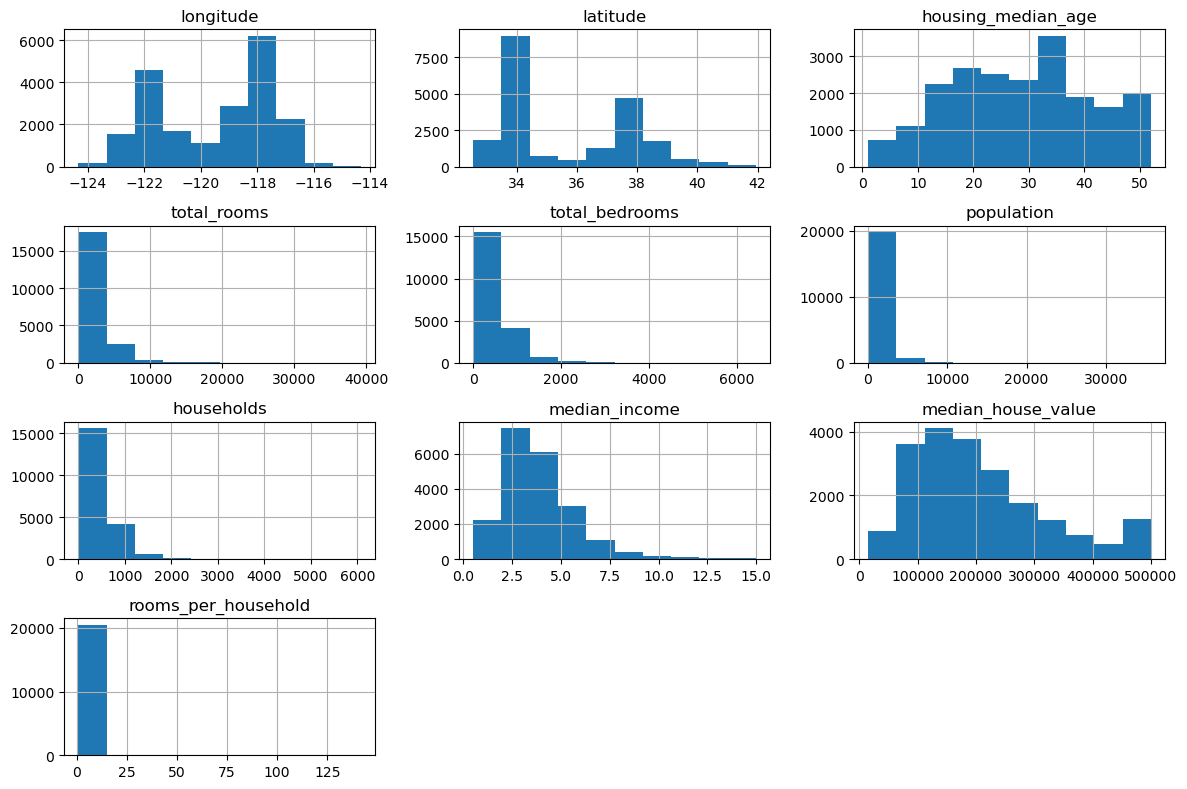

In [9]:
# visualisera fördelningen av numeriska variabler
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

*Fördelning över de numeriska kolumnerna. De flesta kolumnerna har låga värden med några få områden med högre värden som sticker ut. Här syns även dect eventuella outlier-problemet för rooms_per_household - de flesta ligger kring 5 men det finns värden som drar iväg (vilket klumpar ihop datan i första stapeln medan x-axeln sträcker sig långt ut)
Värt att notera är att median_house_value kanske har ett tak i datan då den slutar rätt abrupt på 500 000.*

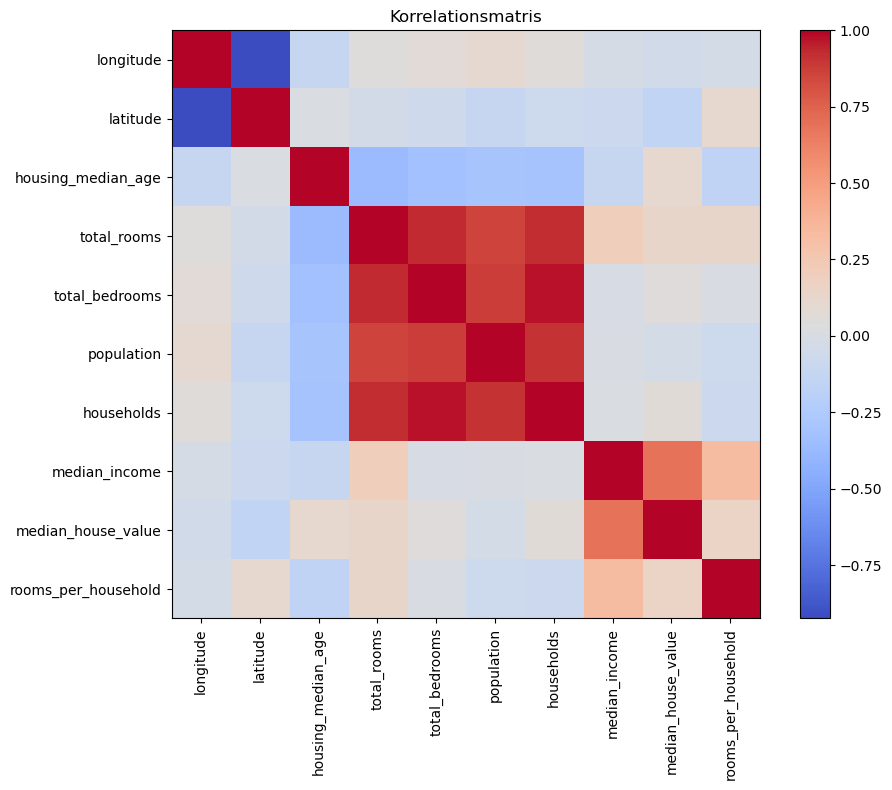

In [10]:
# visualisera korrelationen mellan numeriska variabler
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm')
plt.colorbar(im)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
plt.title("Korrelationsmatris")
plt.tight_layout()
plt.show()

*Korrelationsanalysen visar samband mellan de numeriska kolumnerna i datasetet. Föga förvånande korrelerar population med households, total_bedrooms och total_rooms - ett område med hög population får automatiskt höga värden oavsett storleken på de enskilda bostälderna. 
median_income och median_house_value visar en korrelation vilket också är att förvänta sig. 
totat_rooms har en svag korrelation med median_income.*


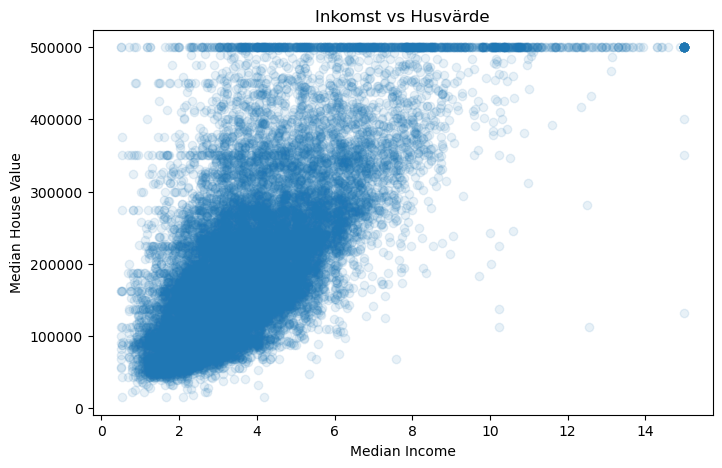

In [11]:
# visualisera sambandet mellan "median_income" och "median_house_value"
plt.figure(figsize=(8, 5))
plt.scatter(df['median_income'], df['median_house_value'], alpha=0.1)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Inkomst vs Husvärde")
plt.show()

*Scatterplot som visar ett positivt samband mellan inkomst och husvärde. Det är dock inte något direkt linjärt samband och det är en stor spridning vilket antyder att fler faktorer påverkar priset.
Även här är det värt att notera gränsen vid 500 00 som även synstes i histogrammet ovan. En konsekvens kan vara att värden ovanför den gränsen inte återspeglas korrekt i datasetet.*

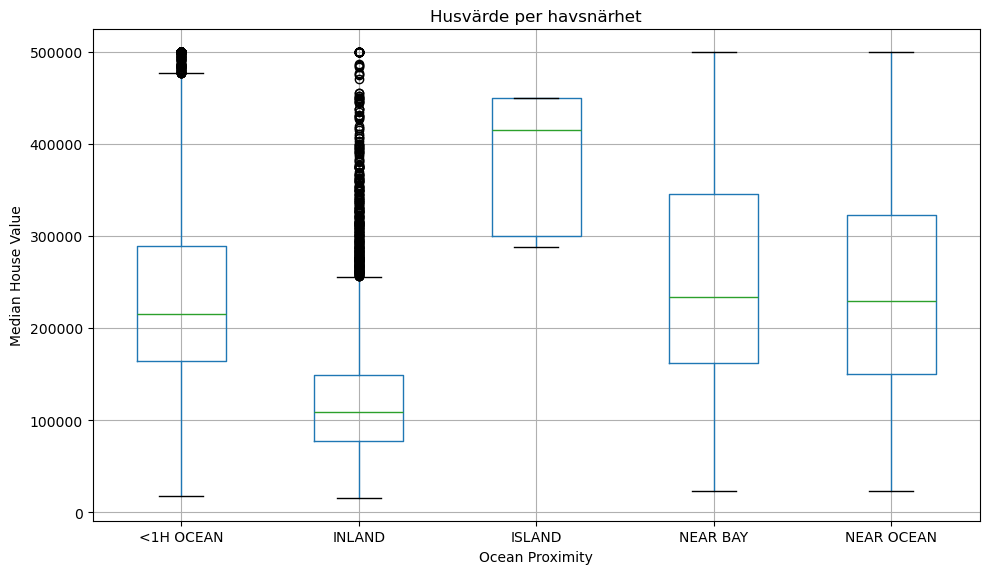

In [12]:
# visualisera sambandet mellan "ocean_proximity" och "median_house_value" med en boxplot
df.boxplot(column='median_house_value', by='ocean_proximity', figsize=(10, 6))
plt.title("Husvärde per havsnärhet")
plt.suptitle("")
plt.xlabel("Ocean Proximity")
plt.ylabel("Median House Value")
plt.tight_layout()
plt.show()

*Boxplot över prisskillnader beroende på läge i förhållande till havet. Inland har lägst medianvärde medan Island ligger högst - notera att det enbart var 5 rader i datasetet med Island i kolumnen ocean_proximity. Det är därför ett för litet underlag för att dra säkra slutsatser. Slutsatser som däremot kan dras är att huspriser verkar ligga betydligt högre närmare kusten (som ses i Near Bay och Near Ocean) - närheten till havet verkar vara en betydande faktor för husvärdet.* 

## Slutsats  
Analysen ovan visar att medelinkomst och geografiskt läge till havet verkar ha störst inverkan på huspriser. Hus närmare kusten brukar rent generellt ha ett högre värde och en högre inkomst i ett område tenderar att samverka med högre slutpriser - en högre inkomst ger en högre ekonomisk möjlighet att köpa dyrare hus.
Datasetet verkar även innehålla några outliers och NULL-värden värt att notera - kolumnen total_bedrooms innehåller 207 NULL-värden, i kolumnen ocean_proximity har enbart 5 rader värdet 'Island'. Det verkar även vara ett tak vid 500 000 gällande husvärdet.  
De olika graferna och visualiseringar påvisar olika samband och korrleationer som ger en djupare bild av datasetet än om bara någon enstaka visualisering hade använts. 


## Självutvärdering
1. Det mest utmanande har varit att hitta tid och fokus samtidigt som ett heltidsarbete. Jag brukar ofta vara trött och fortfarande lite halv-stressad efter en arbetsdag och då känns det inte alltid lockande att sätta sig ner och studera. Förutom självdisciplin har jag laddat ner en gamification-app för att plugga Python som fungerar rätt bra som ett tillägg till boken.
2. Jag hoppas på VG - jag tycker jag visar en analytisk förmåga både gällande diskussionsdelen och EDA:n. Kodandet är inte min starkaste sida (än) då jag är van vid SQL och 'kopplar om' hjärnan men det logiska tänket och resonemanget finns där. Jag tycker jag fått till bra analyser på min EDA och att mina förklaringar i markdowns kan visa det.
3. Inte direkt - jag tycker det har varit bra. Jag ser fram emot att fortsätta nörda ner mig i Python under sommaren för att lära mig mer och att börja närma sig ML till hösten!